In [3]:
import torch, torchvision # pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
from sklearn.model_selection import train_test_split, GroupKFold, StratifiedKFold

import matplotlib.pyplot as plt
import cv2, os, shutil, glob, json, math, datetime, random, gc
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
from time import time
from tqdm import tqdm
from utils.index import *
from tqdm import tqdm

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.ops import nms

from torch.utils.data import DataLoader, Dataset
from torch.utils.data.sampler import SequentialSampler

import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

from utils.Plotter.index import Plotter
pd.set_option('display.max_columns', None)

In [4]:
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()
print(torch.__version__)              # versão do PyTorch
print(torch.cuda.is_available())      # True se detectou a GPU
print(torch.cuda.get_device_name(0))  # nome da GPU
pd.set_option('display.max_columns', None)

2.6.0+cu126
True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [5]:
BATCH_SIZE = 4

# IMPORTANDO DADOS

In [3]:
df = pd.read_csv('Database/DataBase.csv')[:10000]
df['path'] = [os.path.join('../Dataset', path) for path in df.path]
df

,path,label,x_min,y_min,x_max,y_max,frame,isNight,value
0,../Dataset/dayTrain/dayTrain/dayClip1/frames/d...,go,698,333,710,358,0,0,1
1,../Dataset/dayTrain/dayTrain/dayClip1/frames/d...,go,846,391,858,411,0,0,1
2,../Dataset/dayTrain/dayTrain/dayClip1/frames/d...,go,698,337,710,357,1,0,1
3,../Dataset/dayTrain/dayTrain/dayClip1/frames/d...,go,847,390,859,410,1,0,1
4,../Dataset/dayTrain/dayTrain/dayClip1/frames/d...,go,698,331,710,356,2,0,1
...,...,...,...,...,...,...,...,...,...
9995,../Dataset/dayTrain/dayTrain/dayClip13/frames/...,warning,490,149,523,212,188,0,2
9996,../Dataset/dayTrain/dayTrain/dayClip13/frames/...,warning,942,308,966,344,189,0,2
9997,../Dataset/dayTrain/dayTrain/dayClip13/frames/...,warning,642,164,684,227,189,0,2
9998,../Dataset/dayTrain/dayTrain/dayClip13/frames/...,warning,492,158,522,203,189,0,2


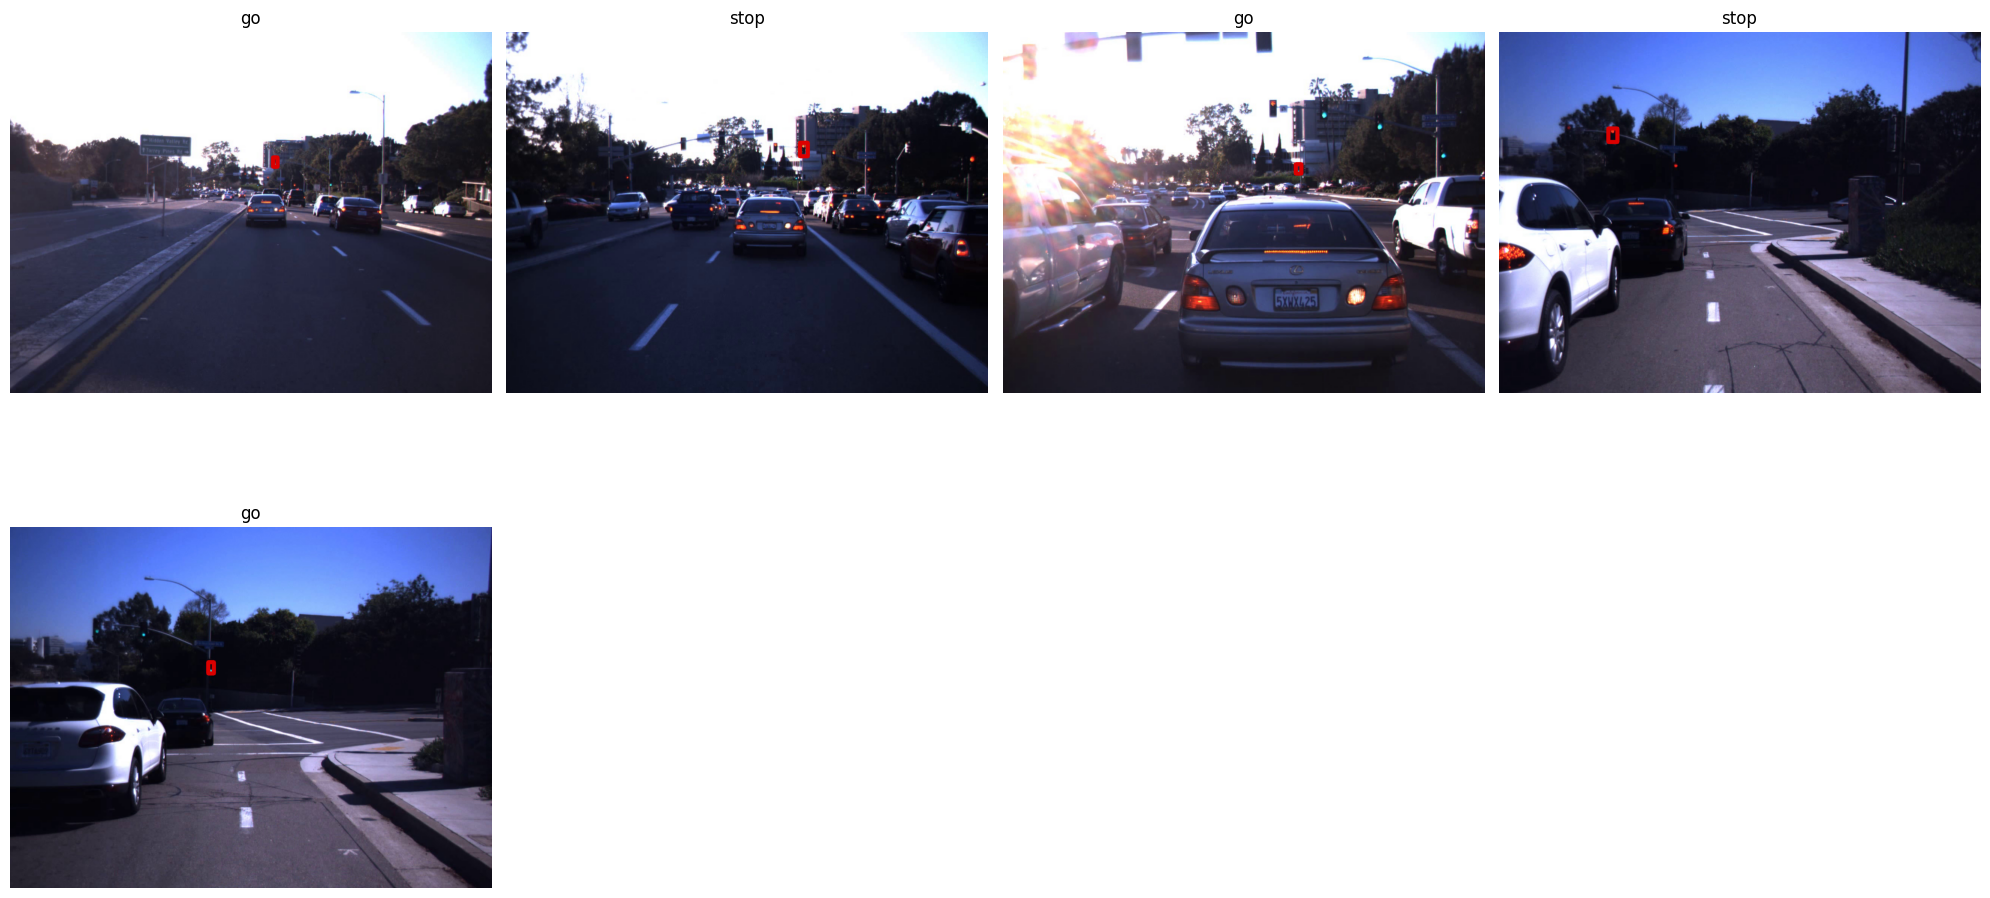

In [4]:
def plotImages(df, limit=None):
    count   = len(df) if limit is None else min(limit, len(df))
    numCols = 4 if count >= 4 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(5*numCols, 5*numRows))
    index = 0
    lastLabel = None
    
    for i, row in df[::500].iterrows():
        if index >= count:
            break

        if lastLabel == row.label:
            continue
        
        img = cv2.imread(row.path, cv2.IMREAD_COLOR_RGB)
        lastLabel = row.label
        index     = index + 1

        plt.subplot(numRows, numCols, index)
        cv2.rectangle(img, (row.x_min, row.y_min), (row.x_max, row.y_max), 220, 10)
        plt.title(row.label)
        plt.imshow(img, cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


plotImages(df, 12)

# SPLITS DOS DADOS
- As we have data from multiple clips, we will have to ensure that all the images from a same clip would either be in the train set or in test set. This will ensure that, there will not be any overlapping between the train & the test data.


In [5]:
VAL_SIZE  = 0.10
TEST_SIZE = 0.10
VAL_SIZE  = VAL_SIZE / (1 - TEST_SIZE)

In [6]:
df.path

0       ../Dataset/dayTrain/dayTrain/dayClip1/frames/d...
1       ../Dataset/dayTrain/dayTrain/dayClip1/frames/d...
2       ../Dataset/dayTrain/dayTrain/dayClip1/frames/d...
3       ../Dataset/dayTrain/dayTrain/dayClip1/frames/d...
4       ../Dataset/dayTrain/dayTrain/dayClip1/frames/d...
                              ...                        
9995    ../Dataset/dayTrain/dayTrain/dayClip13/frames/...
9996    ../Dataset/dayTrain/dayTrain/dayClip13/frames/...
9997    ../Dataset/dayTrain/dayTrain/dayClip13/frames/...
9998    ../Dataset/dayTrain/dayTrain/dayClip13/frames/...
9999    ../Dataset/dayTrain/dayTrain/dayClip13/frames/...
Name: path, Length: 10000, dtype: object

In [7]:
df['img_clip'] = df.path.apply(lambda x: x.split('/')[4])
df['img_clip'].unique()

array(['dayClip1', 'dayClip10', 'dayClip11', 'dayClip12', 'dayClip13'],
      dtype=object)

In [8]:
clipNames  = sorted(df.img_clip.unique())
nightClips = [name for name in clipNames if 'night' in name]
dayClips   = [name for name in clipNames if 'day' in name]

np.random.seed(42)
np.random.shuffle(nightClips)
np.random.shuffle(dayClips)

n_night = len(nightClips)
val_idx_night  = int(round(n_night * VAL_SIZE))
test_idx_night = val_idx_night + int(round(n_night * TEST_SIZE))

n_day = len(dayClips)
val_idx_day  = int(round(n_day * VAL_SIZE))
test_idx_day = val_idx_day + int(round(n_day * TEST_SIZE))

trainClipNames = nightClips[test_idx_night:] + dayClips[test_idx_day:]
valClipNames   = nightClips[:val_idx_night]  + dayClips[:val_idx_day]
testClipNames  = nightClips[val_idx_night:test_idx_night] + dayClips[val_idx_day:test_idx_day]

train_df = df[df.img_clip.isin(trainClipNames)].copy()
val_df   = df[df.img_clip.isin(valClipNames)].copy()
test_df  = df[df.img_clip.isin(testClipNames)].copy()

print(train_df.__len__(), val_df.__len__(), test_df.__len__())

9863 137 0


# MODELO

In [9]:
from Network.index import Network

In [10]:
model_options = {
    'name': 'fasterrcnn',
    'img_size': 512,
    'classes': df.value.unique().__len__() + 1, # + background
    'lr': 0.0001,
    'dropout': 0.1,
    'num_filters': 16
}

network = Network(**model_options)
network.model

FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [11]:
network.classes

4

# DATASET

In [12]:
def resizeImage(size):
    return [
        A.LongestMaxSize(max_size=size, p=1.0),
        A.PadIfNeeded(
            min_height=size, 
            min_width=size, 
            border_mode=cv2.BORDER_CONSTANT, 
            fill=[0, 0, 0],
            p=1.0
        )
    ]

In [ ]:
class Dataset:
    def __init__(self, df, transforms=None):
        super().__init__()
        self.transforms = transforms
        self.paths = df.path.unique()
        self.df    = df
    
    def __len__(self):
        return self.paths.shape[0]

    def __getitem__(self, index):
        path   = self.paths[index]
        target = self.df[self.df.path == path]
        image  = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        boxes  = target[['x_min', 'y_min', 'x_max', 'y_max']].values
        labels = target['value'].values.astype(np.int64)

        if self.transforms: # 2. Apply Albumentations using the NumPy arrays
            sample = {
                'image': image,
                'bboxes': boxes,  # Passing NumPy array
                'labels': labels  # Passing NumPy array
            }
            
            sample = self.transforms(**sample)
            image  = sample['image']
            boxes  = sample['bboxes']
            labels = sample['labels']
        
        boxes  = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        area   = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        
        valid_indices = (area > 0)
        boxes  = boxes[valid_indices]
        labels = labels[valid_indices]
        area   = area[valid_indices]
        
        target = {
            'boxes': boxes,
            'labels': labels,
            'path': torch.tensor([index]),
            'area': area,
            'iscrowd': torch.zeros_like(labels, dtype=torch.int64) 
        }

        return (image, target, path)


trainDataset = Dataset(train_df, transforms=A.Compose(
    resizeImage(network.img_size) + [
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        ToTensorV2(p=1.0)
    ], 
    bbox_params={
        'format': 'pascal_voc', 
        'label_fields': ['labels']
    })
)

valDataset = Dataset(train_df, transforms=A.Compose(
    resizeImage(network.img_size) + [
        ToTensorV2(p=1.0)
    ], 
    bbox_params={
        'format': 'pascal_voc', 
        'label_fields': ['labels']
    })
)

testDataset = Dataset(train_df, transforms=A.Compose(
    resizeImage(network.img_size) + [
        ToTensorV2(p=1.0)
    ], 
    bbox_params={
        'format': 'pascal_voc', 
        'label_fields': ['labels']
    })
)

# DATA LOADER

In [14]:
def collate_fn(batch):
    return tuple(zip(*batch))


trainLoader = DataLoader(
    trainDataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    collate_fn=collate_fn
)

valLoader = DataLoader(
    valDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

testLoader = DataLoader(
    testDataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    collate_fn=collate_fn
)

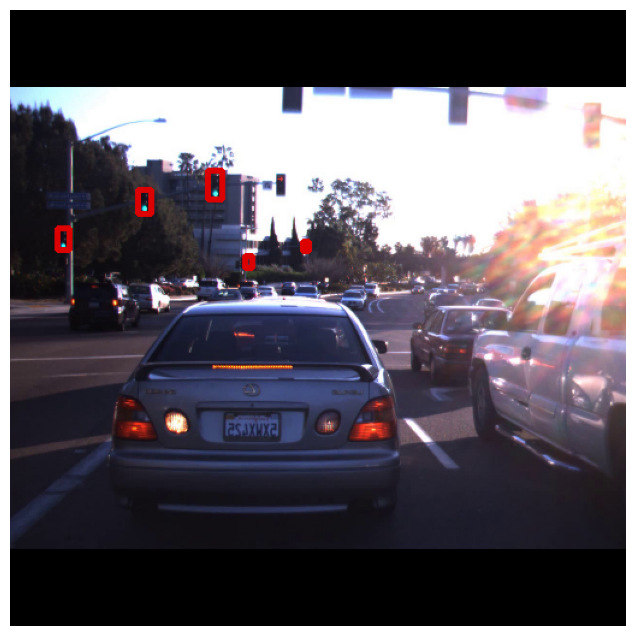

In [15]:
images, targets, paths = next(iter(trainLoader))
boxes = targets[0]['boxes'].cpu().numpy().astype(np.int32)
image = images[0].permute(1,2,0).cpu().numpy()


def displayImage(image, boxes):
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    img = image.copy()
    
    if img.dtype == np.float32 or img.dtype == np.float64:
        img = (img * 255).astype(np.uint8)

    for box in boxes:
        cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (220, 0, 0), 3)

    ax.set_axis_off()
    ax.imshow(img)
    plt.show()


displayImage(image, boxes)

# TREINAMENTO

In [6]:
from Loss.index import Loss
from EarlyStopping.index import EarlyStopping
gc.collect()

11

In [18]:
class Trainer:
    def __init__(self, network, train_loader, val_loader, epochs):
        self.network      = network
        self.train_loader = train_loader
        self.val_loader   = val_loader
        self.epochs       = epochs

        self.early_stopping = EarlyStopping(patience=10, mode='max')
        self.use_amp = True
        self.scaler  = torch.amp.GradScaler('cuda', enabled=self.use_amp)
        
        self.trainLoss = Loss('averager')
        self.valLoss   = Loss('averager')

    def start(self):
        self.history = []
        
        for epoch in range(1, self.epochs + 1):
            print(f"\nEpoch {epoch}/{self.epochs}")
            
            train_loss = self.train() 
            val_loss, val_iou = self.evaluate()

            self.history.append({
                'epoch': epoch,
                'train_loss': train_loss, 
                'val_loss': val_loss,
                'val_iou': val_iou,
                'lr': self.network.optimizer.param_groups[0]['lr']
            })
            
            self.network.scheduler.step(val_loss)
            print(self.history[-1])
                
            with open(f'Database/progress.json', 'w', encoding='utf-8') as file:
                json.dump(self.history[-1], file, ensure_ascii=False, indent=4)

            if self.early_stopping.ready(self.network.model, val_iou):
                break
            
            self.early_stopping.restore_best(self.network.model)

    def train(self):
        loop = tqdm(self.train_loader, desc='Train')
        self.network.model.train()
        self.trainLoss.reset()

        for batch in loop:
            imgs, targets = batch[0], batch[1]
            
            imgs    = list(img.to(self.network.device) for img in imgs)
            targets = [{k: v.to(self.network.device) for k, v in t.items()} for t in targets]
            self.network.optimizer.zero_grad()

            with torch.amp.autocast('cuda', enabled=self.use_amp):
                loss_dict = self.network.model(imgs, targets)
                loss = sum(l for l in loss_dict.values())
            
            self.scaler.scale(loss).backward()
            self.scaler.step(self.network.optimizer)
            self.scaler.update()
            
            self.trainLoss.update(loss.item(), len(imgs))
            loop.set_postfix(loss=self.trainLoss.avg)
        
        return self.trainLoss.avg

    def evaluate(self):
        loop = tqdm(self.val_loader, desc='Val  ')
        self.valLoss.reset()
        self.network.iou.reset()

        with torch.no_grad():
            for batch in loop: 
                imgs, targets = batch[0], batch[1]
                
                imgs = list(img.to(self.network.device) for img in imgs)
                targets = [{k: v.to(self.network.device) for k, v in t.items()} for t in targets]

                with torch.amp.autocast('cuda', enabled=self.use_amp):
                    # 1. Loss
                    self.network.model.train()
                    loss_dict = self.network.model(imgs, targets)
                    loss = sum(l for l in loss_dict.values())
                    
                    # 2. Predições e IoU
                    self.network.model.eval()
                    outputs   = self.network.model(imgs)
                    batch_iou = self.network.iou.update(outputs, targets)
                
                self.valLoss.update(loss.item(), len(imgs))
                loop.set_postfix(loss=self.valLoss.avg, iou=batch_iou)
        
        iou, _ = self.network.iou.compute()
        return (self.valLoss.avg, iou)


trainer = Trainer(network, trainLoader, valLoader, epochs=2)
trainer.start()


Epoch 1/2


Val  : 100%|██████████| 711/711 [06:10<00:00,  1.92it/s, iou=0, loss=0.119]     


{'epoch': 1, 'train_loss': 0.18048190323139973, 'val_loss': 0.11896659647164695, 'val_iou': 0.5209497125595818, 'lr': 0.0001}

Epoch 2/2


Val  : 100%|██████████| 711/711 [06:13<00:00,  1.90it/s, iou=0.152, loss=0.0914] 

{'epoch': 2, 'train_loss': 0.10735746830272037, 'val_loss': 0.09136321695702955, 'val_iou': 0.6747257086923296, 'lr': 0.0001}
(earling stopping) model improved to 0.675


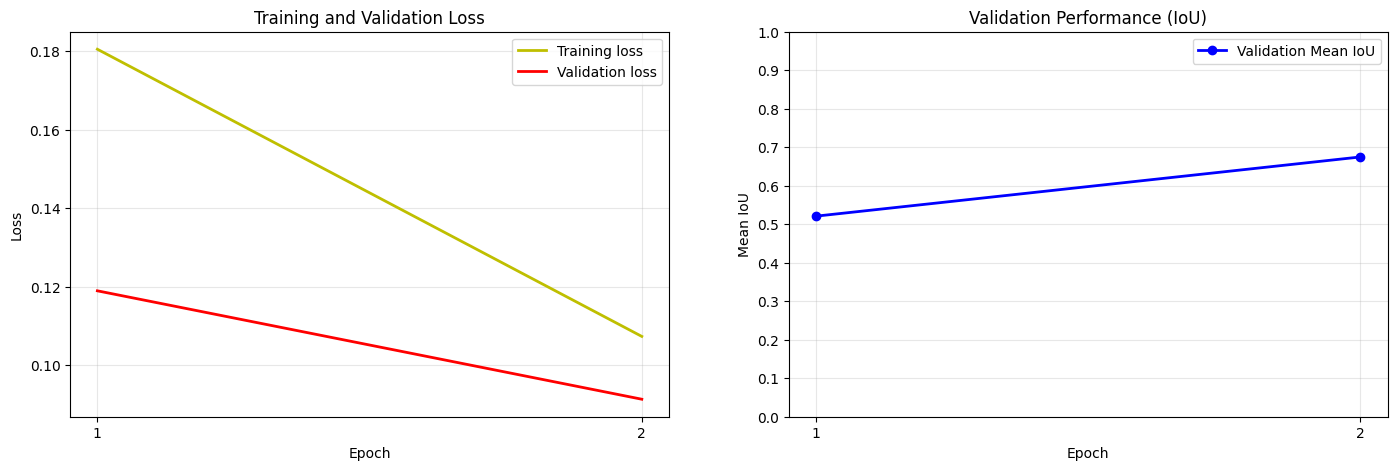

In [31]:
def plotHistory(history, save=None):
    plt.figure(figsize=(17, 5))

    plt.subplot(1, 2, 1)
    plt.plot([h.get('epoch') for h in history], [h.get('train_loss') for h in history], 'y', label='Training loss', linewidth=2)
    plt.plot([h.get('epoch') for h in history], [h.get('val_loss')   for h in history], 'r', label='Validation loss', linewidth=2)
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch'), plt.ylabel('Loss')
    if trainer.epochs < 10: plt.xticks([i for i in range(1, trainer.epochs+1)])
    plt.legend(), plt.grid(alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot([h.get('epoch') for h in history], [h.get('val_iou') for h in history], 'b', label='Validation Mean IoU', linewidth=2, marker='o')
    plt.title('Validation Performance (IoU)')
    plt.xlabel('Epoch'), plt.ylabel('Mean IoU')
    plt.legend(), plt.grid(alpha=0.3)
    plt.gca().set_ylim(0, 1)
    if trainer.epochs < 10: plt.xticks([i for i in range(1, trainer.epochs+1)])
    plt.yticks([c / 10 for c in range(11)])

    if not save:
        return plt.show()

    os.makedirs(os.path.dirname(save), exist_ok=True)
    plt.savefig(save, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()


plotHistory(trainer.history)

# DADOS DE TESTE

In [20]:
from Matrix.index import ConfusionMatrix

In [21]:
trainer.network.model.eval()
matrix  = ConfusionMatrix(num_classes=trainer.network.classes)
trainer.network.iou.reset()

with torch.no_grad():
    for imgs, targets, paths in tqdm(testLoader, desc="Testing..."):
        imgs = list(img.to(trainer.network.device) for img in imgs)
        targets = [{k: v.to(trainer.network.device) for k, v in t.items()} for t in targets]
        outputs = trainer.network.model(imgs)
        
        trainer.network.iou.update(outputs, targets)
        matrix.update(outputs, targets)

test_iou, iouData = trainer.network.iou.compute()
iouData.update({'mean': test_iou})
iouData

Testing...: 100%|██████████| 711/711 [04:42<00:00,  2.52it/s]


{1: 0.8338870847813762,
 2: 0.336306137771442,
 3: 0.865614149859092,
 'mean': 0.6786024574706367}

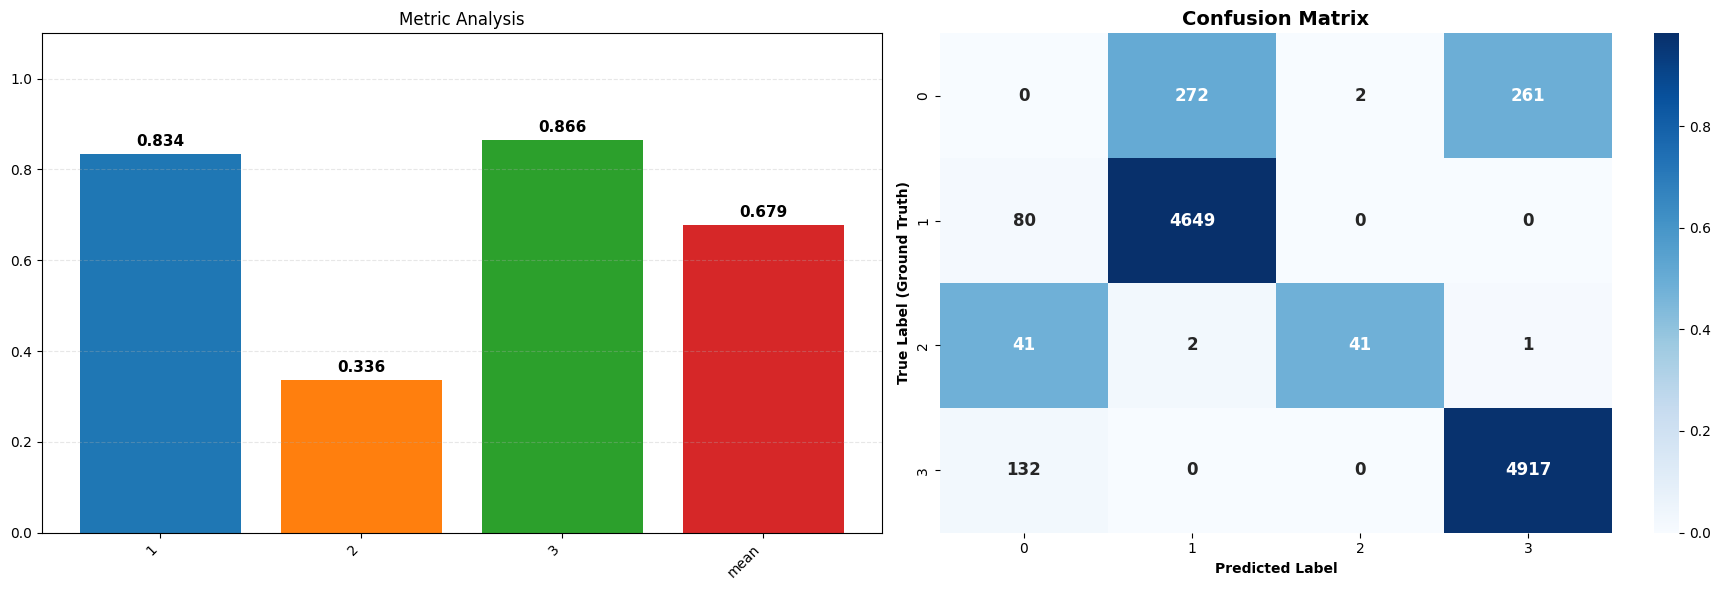

In [27]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
Plotter({str(k): val for k, val in iouData.items()}) 
plt.subplot(1, 2, 2)
matrix.plot() 
plt.tight_layout()
plt.show()

### Predições

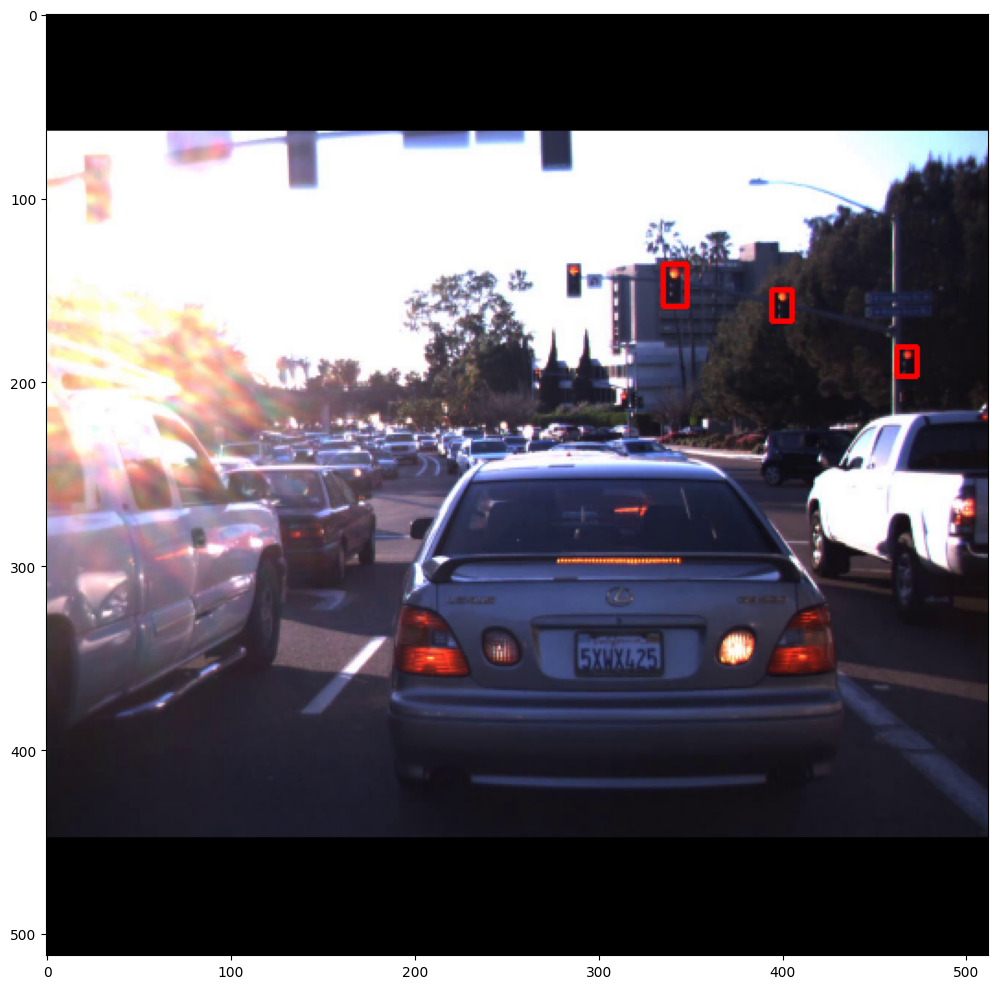

In [32]:
class InferenceVisualizer:
    def __init__(self, model, dataset, class_names, device='cuda', score_threshold=0.5, nms_threshold=0.3):
        self.model   = model
        self.dataset = dataset
        self.class_names = class_names
        self.device = device
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold

    def getRandom(self, num_images=3):
        """Puxa imagens aleatórias do Dataset de Teste e exibe"""
        self.model.eval()
        indices = random.sample(range(len(self.dataset)), min(num_images, len(self.dataset)))
        for idx in indices:
            self.plot(idx)

    def fromPath(self, target_path):
        self.model.eval()
        idx = list(self.dataset.paths).index(target_path)
        self.plot(idx)

    def plot(self, idx):
        image, target, path = self.dataset[idx]

        with torch.no_grad():
            output = self.model(image.unsqueeze(0).to(self.device))[0]
            
        boxes, scores, labels = output['boxes'], output['scores'], output['labels']
        mask = nms(boxes, scores, self.nms_threshold)
        boxes, scores, labels = boxes[mask], scores[mask], labels[mask]
        
        score_mask  = scores >= self.score_threshold
        pred_boxes  = boxes[score_mask].cpu().numpy().astype(np.int32)
        pred_scores = scores[score_mask].cpu().numpy()
        pred_labels = labels[score_mask].cpu().numpy()
        
        # 4. Pega os Ground Truths (Dados Reais)
        gt_boxes  = target['boxes'].cpu().numpy().astype(np.int32)
        gt_labels = target['labels'].cpu().numpy()
        
        img = (image.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8).copy()
        
        for box, label, score in zip(pred_boxes, pred_labels, pred_scores):
            class_name = self.class_names.get(label, str(label))
            cv2.rectangle(img, (box[0], box[1]), (box[2], box[3]), (255, 0, 0), 2)

        plt.figure(figsize=(14, 10))
        plt.imshow(img)
        plt.tight_layout()
        plt.show()


visualizer = InferenceVisualizer(
    model=trainer.network.model, 
    dataset=testDataset, 
    class_names={1: 'Verde', 2: 'Amarelo', 3: 'Vermelho'}, 
    device=trainer.network.device,
    score_threshold=0.5,
    nms_threshold=0.3
)

visualizer.getRandom(1)

In [33]:
visualizer.fromPath(test_df.path.iloc[0])

IndexError: single positional indexer is out-of-bounds

# SALVANDO MODELO

In [34]:
os.makedirs('Backup/', exist_ok=True)
files   = os.listdir('Backup/')
indexes = sorted([int(path.split('_')[-1]) for path in files if path.startswith('model_')]) if len(files) > 0 else [0]
index  = indexes[-1] + 1
folder = f'Backup/model_{index}'
os.makedirs(folder, exist_ok=True)
folder

'Backup/model_1'

In [35]:
data = {
    'network': model_options,
    'test_iou': iouData
}
    
with open(f'{folder}/info.json', 'w', encoding='utf-8') as file:
    json.dump(data, file, ensure_ascii=False, indent=4)

plotHistory(trainer.history, f'{folder}/train.png') 
torch.save(trainer.network.model.state_dict(), os.path.join(folder, 'model.pth'))

<Figure size 1800x600 with 0 Axes>

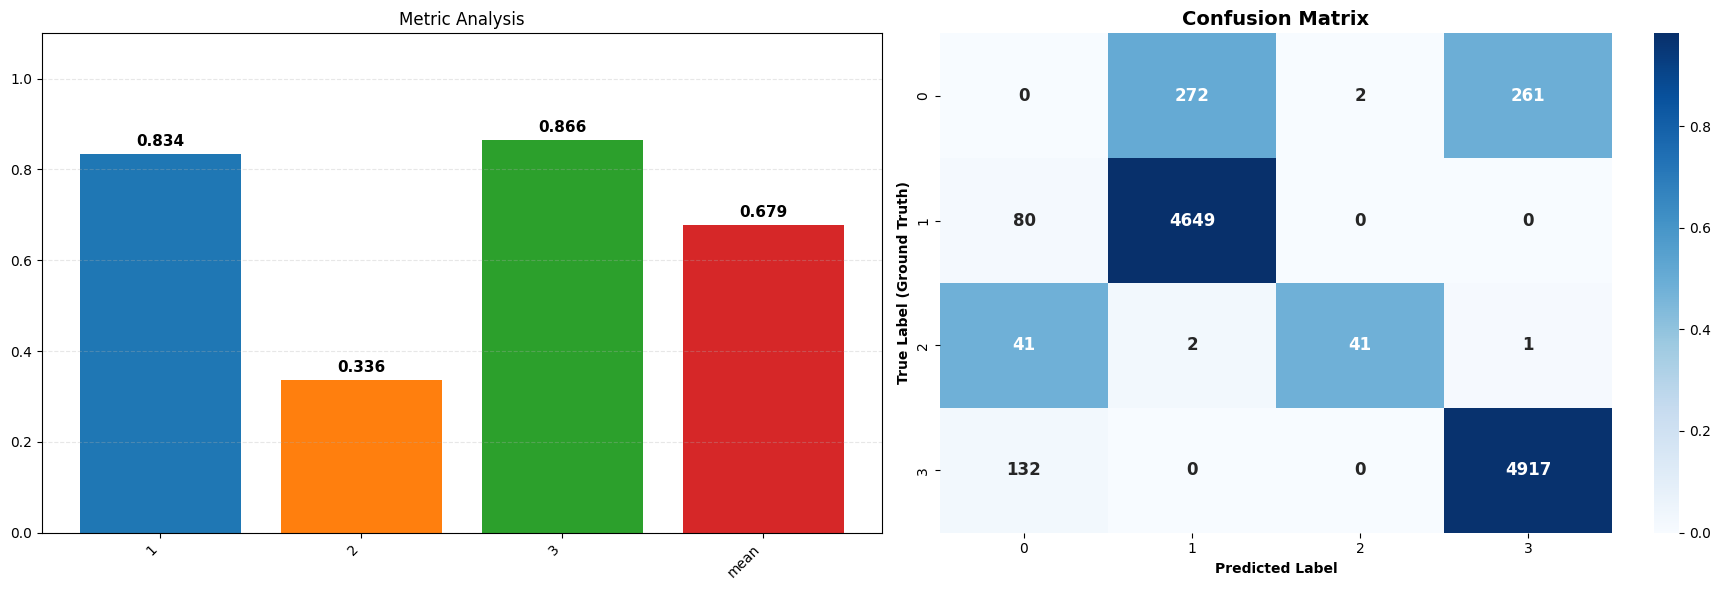

In [ ]:
plt.figure(figsize=(18, 6))
plt.subplot(1, 2, 1)
Plotter({str(k): val for k, val in iouData.items()}) 
plt.subplot(1, 2, 2)
matrix.plot() 
plt.tight_layout()
plt.savefig(os.path.join(folder, 'test.png'))